ONE HOT ENCODING

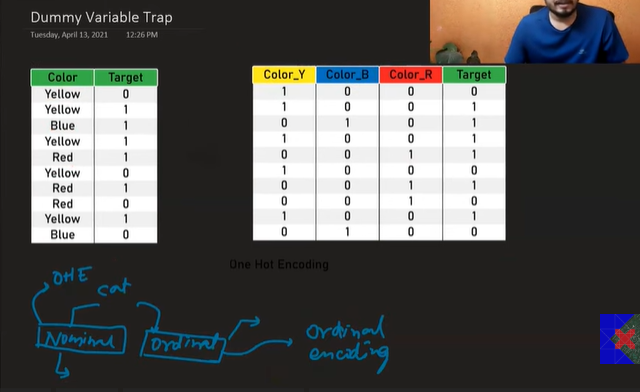


In [1]:
import pandas as pd 
import numpy as np 


In [2]:
df = pd.read_csv('cars.csv')

In [3]:
df.sample(5)

,brand,km_driven,fuel,owner,selling_price
6848,Maruti,70000,Petrol,Second Owner,70000
506,Tata,146000,Diesel,Second Owner,250000
3430,Hyundai,60000,Diesel,Second Owner,459999
4186,Renault,34000,Petrol,First Owner,300000
5784,Maruti,47370,CNG,First Owner,330000


In [4]:
df.shape

(8128, 5)

In [14]:
df['brand'].nunique()

32

In [16]:
df['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

1. OneHotEncoding using pandas

In [21]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=int)
#FIRST OWNER AND CNG HAT GAYA NOW MEANS WHEN ALL 0 THEN IT IS FIRST OWNER AND IF FUEL CATEGORY ALL 0 THEN CNG

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


2. K-1 OneHotEncoding

In [20]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True,dtype=int)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


3. OneHotEncoding using Sklearn

In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=0)

In [24]:
X_train.head()

,brand,km_driven,fuel,owner
3042,Hyundai,60000,LPG,First Owner
1520,Tata,150000,Diesel,Third Owner
2611,Hyundai,110000,Diesel,Second Owner
3544,Mahindra,28000,Diesel,Second Owner
4138,Maruti,15000,Petrol,First Owner


In [27]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe = OneHotEncoder(drop='first',sparse_output=False,dtype=np.int32)
#BY DEFAULT OHE CREATES A SPARSE MATRIX WITH ONLY '1'S AND IGNORING ALL '0'S BUT SINCE BY DOING THAT NP.HSTACK WOULDN'T WORK PROPERLY WE DO SPARSE=FALSE AND MAKING OHE CREATE A NORMAL NUMPY DENSE MATRIX

In [58]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])

In [59]:
X_test_new = ohe.transform(X_test[['fuel','owner']])

In [ ]:
np.hstack((X_train[['brand','km_driven']].values,X_train_new))
#NP.HSTACK IS USED TO COMBINE THE ORIGINAL UNMODIFIED COLUMNS[BRAND AND KM_DRIVEN] AND THE OTHER MODIFIED OWNER AND FUEL COLUMNS TOGETHER

array([['Hyundai', 60000, 0, ..., 0, 0, 0],
       ['Tata', 150000, 1, ..., 0, 0, 1],
       ['Hyundai', 110000, 1, ..., 1, 0, 0],
       ...,
       ['Hyundai', 90000, 0, ..., 1, 0, 0],
       ['Volkswagen', 90000, 1, ..., 0, 0, 0],
       ['Hyundai', 110000, 0, ..., 0, 0, 0]],
      shape=(6502, 9), dtype=object)

4. OneHotEncoding with Top Categories

In [64]:
counts = df['brand'].value_counts()

In [66]:
df['brand'].nunique()
threshold = 100

In [70]:
repl = counts[counts<=threshold].index

In [75]:
pd.get_dummies(df['brand'].replace(repl,'uncommon'),dtype=np.int32)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Renault,Skoda,Tata,Toyota,Volkswagen,uncommon
0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,0,0,0,0,1,0,0,0,0,0,0,0,0
8124,0,0,0,0,1,0,0,0,0,0,0,0,0
8125,0,0,0,0,0,0,1,0,0,0,0,0,0
8126,0,0,0,0,0,0,0,0,0,1,0,0,0
